In [13]:
import numpy as np
import pandas as pd
import joblib
from IPython import display

import matplotlib.pyplot as plt
import seaborn as sns
# --- CÀI ĐẶT CHO BIỂU ĐỒ ---
# Cài đặt style và font chữ để hiển thị đẹp hơn
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Segoe UI' # Hoặc 'Arial', 'Helvetica'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.figsize'] = (12, 7)

import os
import logging
import time
from datetime import datetime

#from pandas.tools.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# Các công cụ lựa chọn đặc trưng
from sklearn.feature_selection import RFECV, SelectFromModel
# Khai báo thư viện cho mô hình phân loại đa lớp
from sklearn.linear_model import LogisticRegression# Mô hình tuyến tính
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis# Phân tích tuyến tính
from sklearn.tree import DecisionTreeClassifier, export_graphviz# Cây quyết định
from sklearn.neighbors import KNeighborsClassifier# Mô hình khoảng cách (k-láng giềng)
from sklearn.svm import SVC# Mô hình SVM (máy vector hỗ trợ)
from sklearn.naive_bayes import GaussianNB# Mô hình xác suất
from sklearn.neural_network import MLPClassifier# Mạng nơ-ron đơn giản (đa lớp)
from sklearn.ensemble import RandomForestClassifier#rừng ngẫu nhiên
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import graphviz

import warnings
# Tắt các cảnh báo không cần thiết
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [14]:
save_dir = "Data_clean"
npz_path = os.path.join(save_dir, 'model_data.npz')

try:
    data = np.load(npz_path, allow_pickle=True)
    # Lấy tên cột từ file train_final.csv để đảm bảo chính xác
    train_csv_path = os.path.join(save_dir, 'data_cleaned.csv')
    df_train_final = pd.read_csv(train_csv_path)
    feature_columns = [col for col in df_train_final.columns if col not in ['diabetes']]
    
    X_train = pd.DataFrame(data['X_train'], columns=feature_columns)
    X_test = pd.DataFrame(data['X_test'], columns=feature_columns)
    y_train = data['y_train']
    y_test = data['y_test']
    
    print(f"Tải dữ liệu thành công. Kích thước X_train: {X_train.shape}, X_test: {X_test.shape}")
except Exception as e:
    print(f"Lỗi khi tải dữ liệu: {e}. Hãy đảm bảo bạn đã chạy pipeline chuẩn bị dữ liệu trước.")
    exit()

Tải dữ liệu thành công. Kích thước X_train: (67302, 8), X_test: (28844, 8)


In [15]:
X_train.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1.0,0.485714,0.0,0.0,0.25,-0.255814,0.142857,-0.847458
1,1.0,-0.428571,0.0,0.0,0.25,-0.303876,-1.642857,0.338983
2,1.0,-0.342857,0.0,0.0,0.25,0.000000,0.285714,1.016949
3,0.0,-1.142857,0.0,0.0,0.25,-1.218605,-0.714286,0.254237
4,0.0,0.057143,0.0,1.0,-0.50,-1.086822,0.285714,-0.169492


In [16]:
dt = DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)
y_pred_base = dt.predict(X_train)
print(f"Độ chính xác (Accuracy) của cây mặc định: {accuracy_score(y_train, y_pred_base):.4f}")


Độ chính xác (Accuracy) của cây mặc định: 0.9706


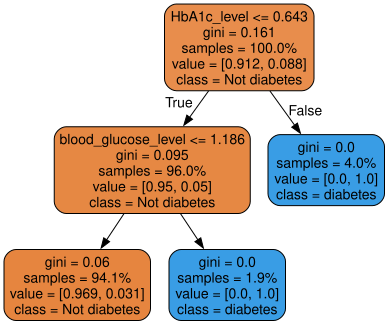

In [18]:
features_response = X_train.columns.tolist()

dot_data = export_graphviz(dt, out_file=None,filled=True,rounded=True,
                             feature_names=features_response, proportion=True, class_names=['Not diabetes', 'diabetes'])

graph = graphviz.Source(dot_data)
graph

## **Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau**

Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu

In [19]:
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]}
dt = DecisionTreeClassifier()
cv = GridSearchCV(dt, param_grid=params, scoring = 'roc_auc',
                  n_jobs = None, refit = True, cv = 4, verbose=1,
                  error_score=np.nan,
                  return_train_score=True) 
cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
C:\Users\DELL\AppData\Local\Temp\ipykernel_15516\286894924.py:8: SyntaxWarning: invalid escape sequence '\p'
  label = 'Mean $\pm$ 1 SE train scores')
C:\Users\DELL\AppData\Local\Temp\ipykernel_15516\286894924.py:13: SyntaxWarning: invalid escape sequence '\p'
  label = 'Mean $\pm$ 1 SE test scores')


Text(0, 0.5, 'ROC AUC')

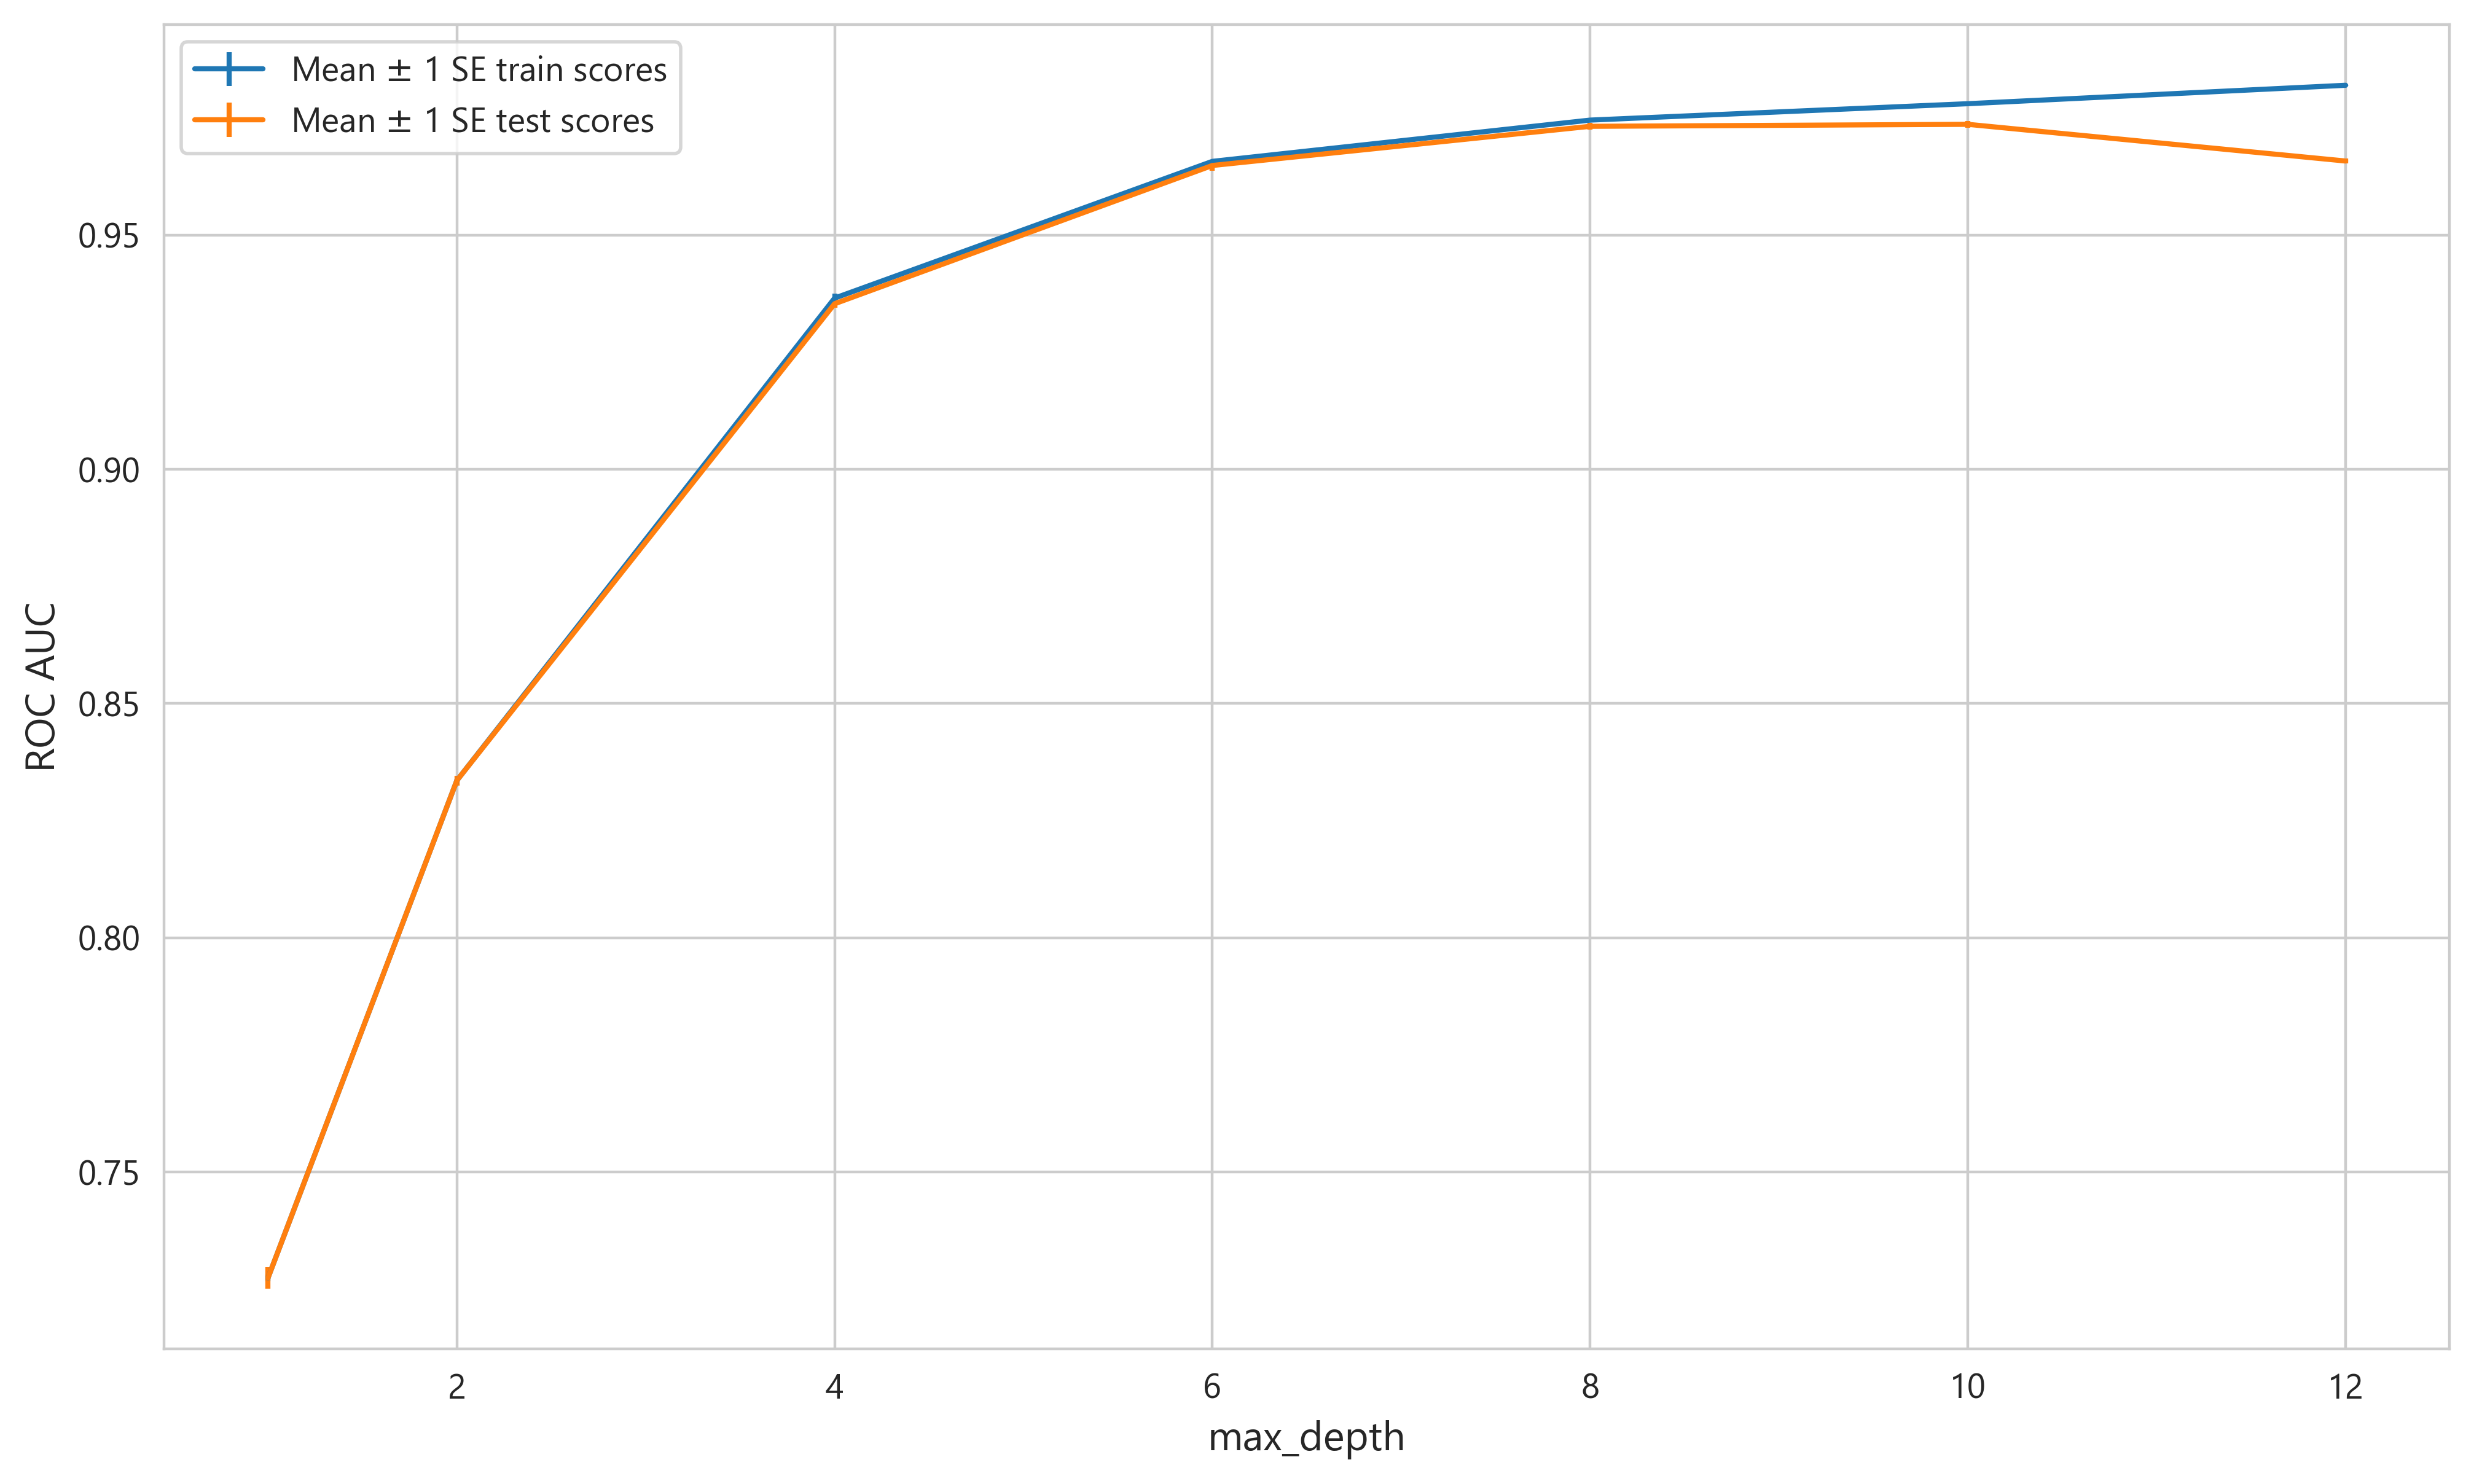

In [20]:
cv_resuls_df = pd.DataFrame(cv.cv_results_)

cv_resuls_df.columns
ax = plt.axes()
ax.errorbar(cv_resuls_df['param_max_depth'],
            cv_resuls_df['mean_train_score'],
            yerr=cv_resuls_df['std_train_score']/np.sqrt(4),
            label = 'Mean $\pm$ 1 SE train scores')

ax.errorbar(cv_resuls_df['param_max_depth'],
            cv_resuls_df['mean_test_score'],
            yerr=cv_resuls_df['std_test_score']/np.sqrt(4),
            label = 'Mean $\pm$ 1 SE test scores')

ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')

## **Nhiệm vụ 3: Xây dựng rừng cây (random forest)**

1. Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu 
2. Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn 

In [21]:

rf = RandomForestClassifier(n_estimators=10, criterion='gini', max_depth=3,
                            min_samples_split=2, min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0, max_features='sqrt',
                            max_leaf_nodes=None, min_impurity_decrease=0.0,
                            bootstrap=True, oob_score=False, n_jobs=None,
                            random_state=4, verbose=0, warm_start=False, class_weight=None)

3. Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [22]:
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex, scoring='roc_auc',
                        n_jobs=None, refit=True, cv=4, verbose=1,
                        error_score=0.0,
                        return_train_score=True)
cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,0.0
,return_train_score,True
,n_estimators,30


4. Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau 

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
C:\Users\DELL\AppData\Local\Temp\ipykernel_15516\1085417108.py:15: SyntaxWarning: invalid escape sequence '\p'
  axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')


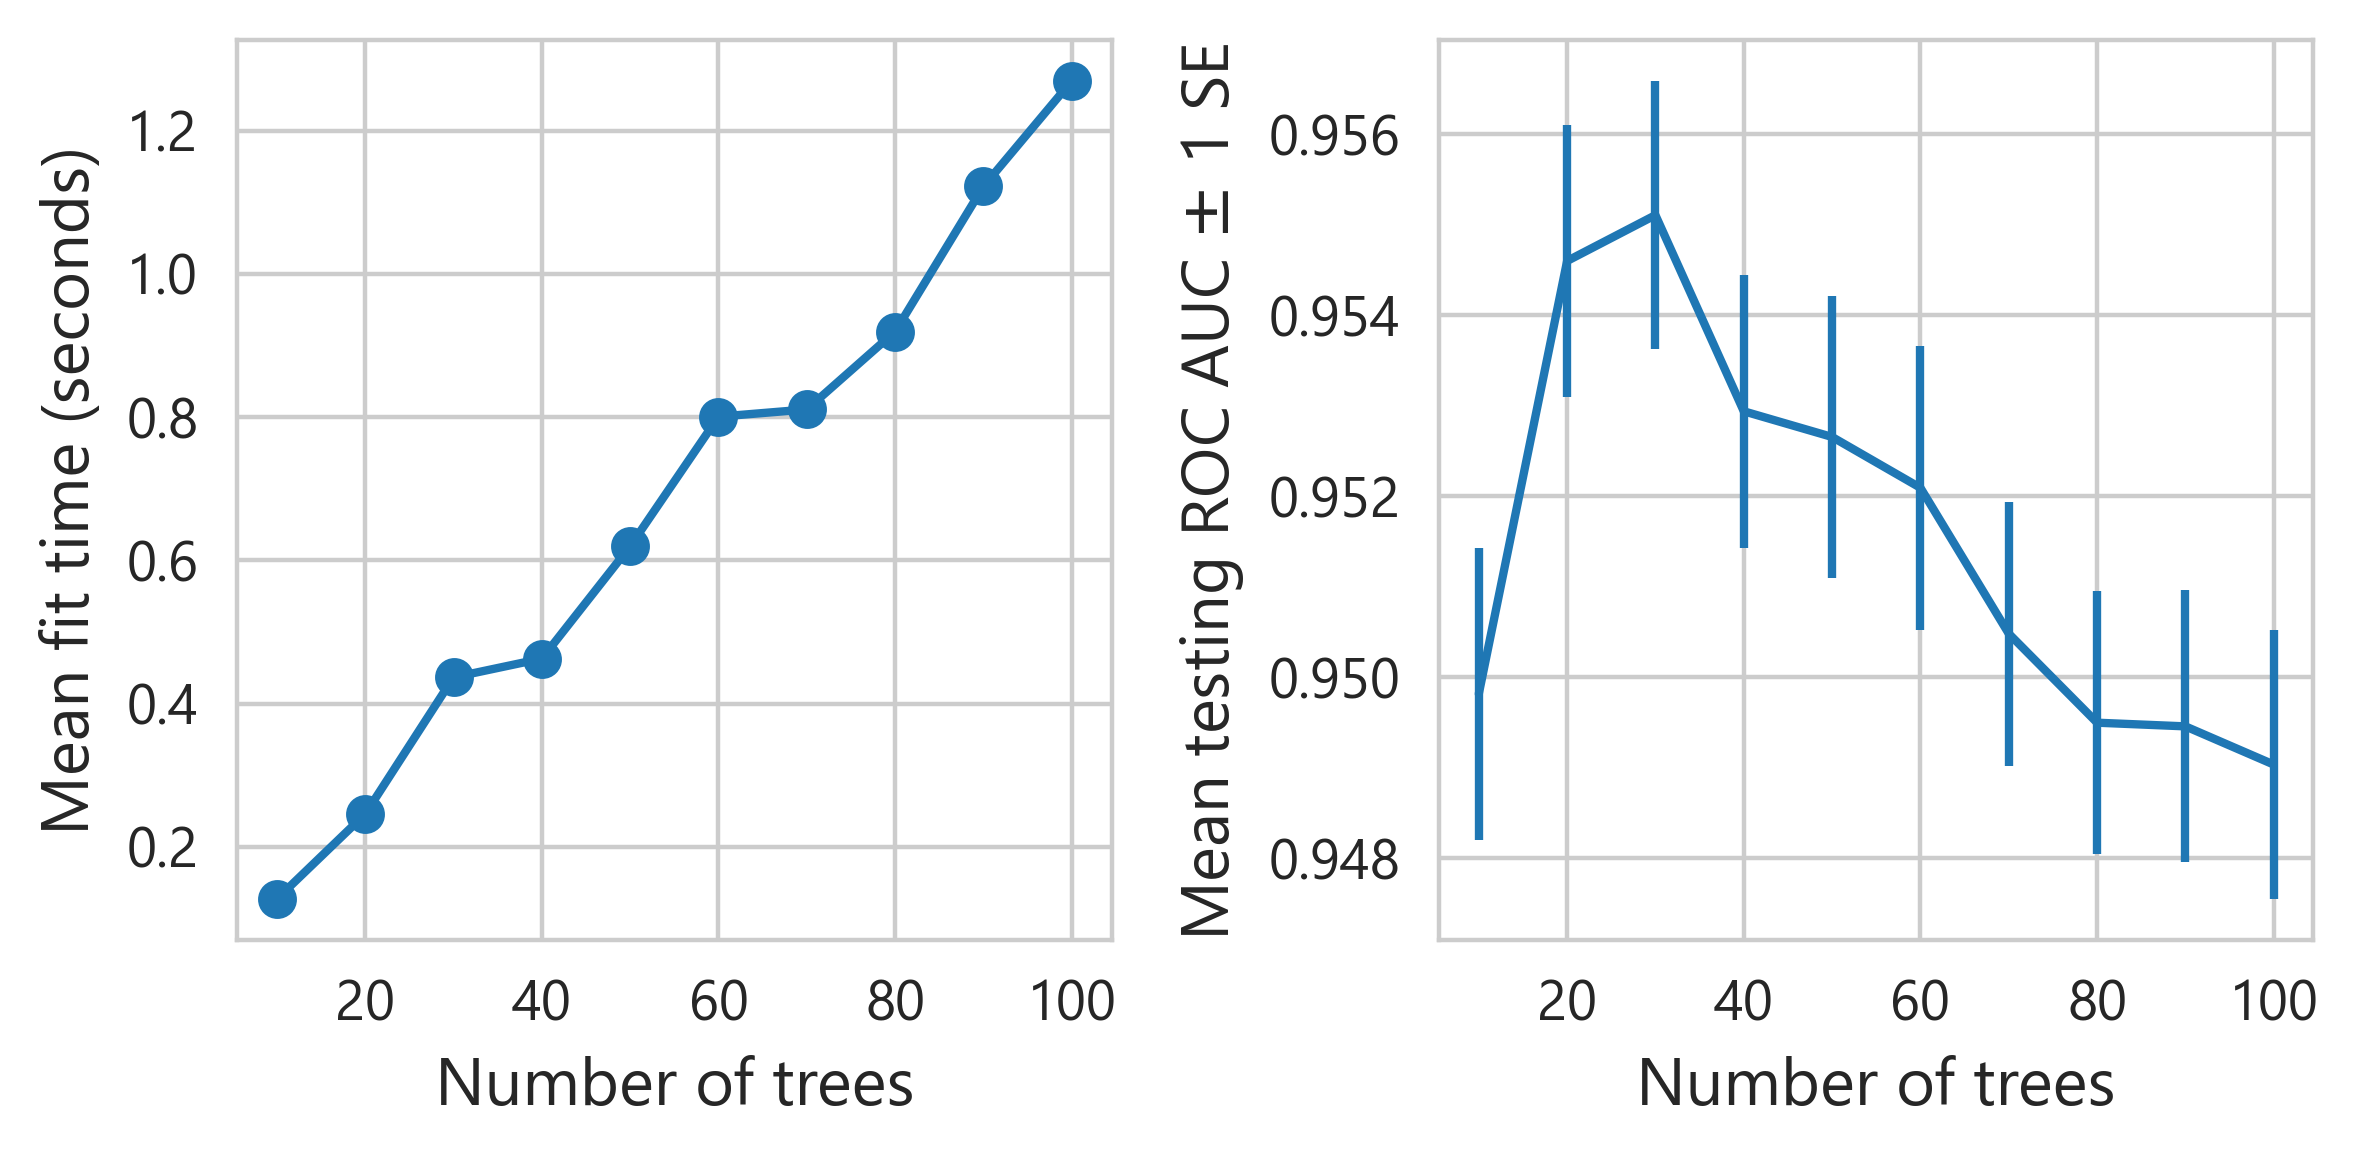

In [23]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_) 
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3)) 

axs[0].plot(cv_rf_ex_results_df['param_n_estimators'], 
cv_rf_ex_results_df['mean_fit_time'], '-o') 

axs[0].set_xlabel('Number of trees') 
axs[0].set_ylabel('Mean fit time (seconds)') 

axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'], 
cv_rf_ex_results_df['mean_test_score'], 
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4)) 

axs[1].set_xlabel('Number of trees') 
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ') 
plt.tight_layout() 

5. Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham 
số tốt nhất

<Axes: >

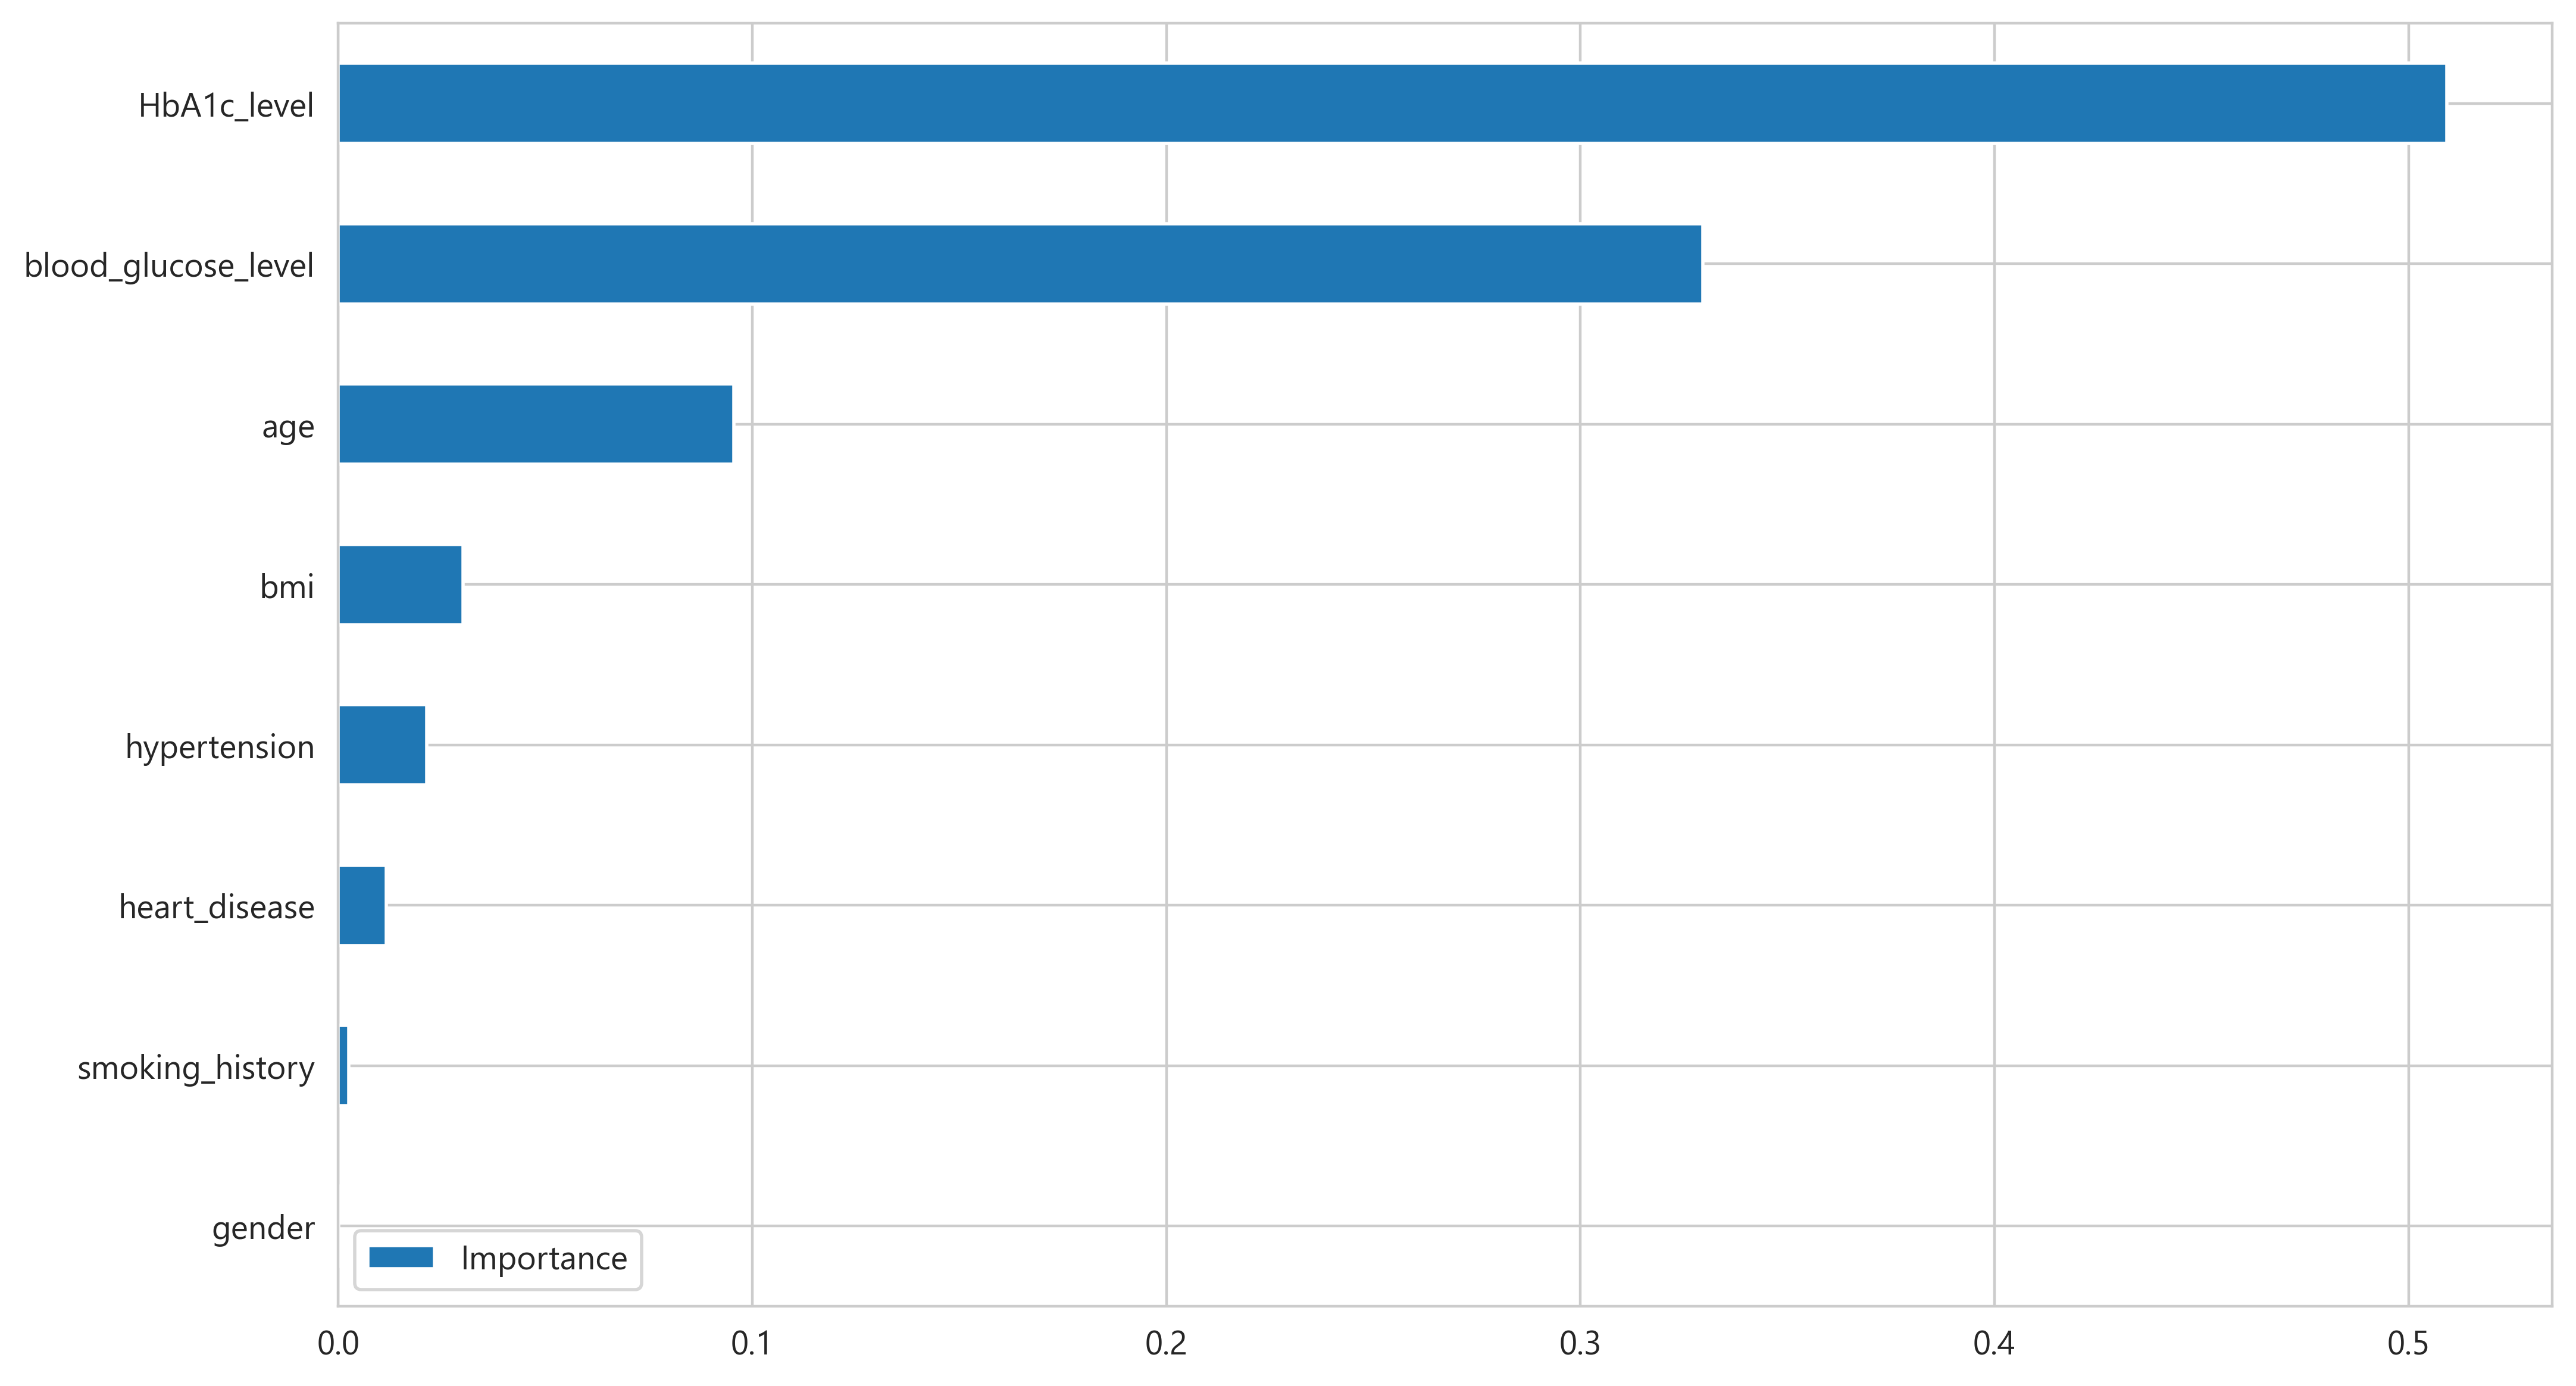

In [25]:
# {'n_estimators': 50} 
cv_rf_ex.best_params_ 
# the feature names and importances 
feat_imp_df = pd.DataFrame({ 
'Importance':cv_rf_ex.best_estimator_.feature_importances_}, 
index=features_response) 
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()